In [176]:
import os

import numpy as np
import pandas as pd
from features import *
import matplotlib.pyplot as plt
import ast
import seaborn as sns

In [177]:
def complete_dict(list_dataframe, cleaness):
    if cleaness == 0:
        path = "../Data/train/with_label/clean"
    elif cleaness == 1:
        path = "../Data/train/with_label/dirty"
    else:
        path = "../Data/train/with_label/very_dirty"
    for e in os.scandir(path):
        if e.is_file():
            dict = {}
            path = e.path
            dict['name'] = e.name
            features_img = extract_features(path)
            for key in features_img.keys():
                dict[key] = features_img[key]
            if cleaness == 0 :
                dict['class'] = 'clean'
            elif cleaness == 1:
                dict['class'] = 'dirty'
            else:
                dict['class'] = 'very_dirty'
            list_dataframe.append(dict)

In [178]:
def get_dataframe() -> list:
    list_dataframe = []

    complete_dict(list_dataframe, 0)    
    # complete_dict(list_dataframe, 1)
    complete_dict(list_dataframe, 2)

    return list_dataframe

In [179]:
list_df = get_dataframe()
df = pd.DataFrame(list_df)
df[['file_size', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'saturation', 'edge_density', 'contraste_global', 'edge_density_V2']] = df[['file_size', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'saturation', 'edge_density', 'contraste_global', 'edge_density_V2']].astype(float)
df[['image_width', 'image_height', 'contraste_maximal']] = df[['image_width', 'image_height', 'contraste_maximal']].astype(int)

In [180]:
df

,name,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste_maximal,contraste_global,saturation,hist_rgb,hist_luminance,edge_density,edge_density_V2,class
0,train_clean_img_001.jpeg,69.07,600,600,122.39,127.30,121.97,125.22429,255,56.431538,29.08,"{""red"": [110, 28, 27, 20, 38, 36, 58, 58, 73, ...","[1, 33, 27, 15, 22, 21, 28, 35, 37, 45, 41, 61...",0.1123,52889.0,clean
1,train_clean_img_002.jpeg,35.45,600,529,106.65,114.13,105.04,110.85722,254,52.839565,35.08,"{""red"": [8, 3, 1, 5, 2, 7, 12, 31, 34, 36, 61,...","[0, 1, 3, 1, 9, 4, 13, 18, 31, 56, 82, 84, 82,...",0.0545,23010.0,clean
2,train_clean_img_003.jpeg,57.77,600,688,122.54,121.58,120.12,121.70060,255,39.285750,44.79,"{""red"": [52, 27, 31, 31, 43, 41, 58, 51, 60, 5...","[3, 13, 10, 18, 36, 33, 41, 48, 59, 75, 61, 67...",0.0541,52980.0,clean
3,train_clean_img_004.jpeg,47.19,600,600,130.69,132.25,129.66,131.48830,254,44.082533,17.20,"{""red"": [8, 1, 3, 7, 12, 6, 14, 12, 23, 23, 25...","[0, 4, 2, 4, 2, 3, 9, 13, 15, 20, 22, 30, 41, ...",0.0677,37542.0,clean
4,train_clean_img_005.jpeg,192.64,1382,1496,111.27,109.90,101.31,109.33037,255,48.528542,40.16,"{""red"": [65, 40, 38, 86, 154, 289, 469, 834, 1...","[11, 44, 69, 108, 240, 408, 844, 1573, 2059, 2...",0.0330,112613.0,clean
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,train_no_label_img_512.jpeg,276.22,600,338,133.58,128.67,120.25,129.17821,255,70.702186,65.50,"{""red"": [61, 26, 27, 20, 32, 55, 65, 105, 167,...","[4, 2, 4, 8, 12, 16, 34, 65, 138, 164, 225, 26...",0.1471,41776.0,very_dirty
86,train_no_label_img_515.jpeg,276.22,600,338,133.58,128.67,120.25,129.17821,255,70.702186,65.50,"{""red"": [61, 26, 27, 20, 32, 55, 65, 105, 167,...","[4, 2, 4, 8, 12, 16, 34, 65, 138, 164, 225, 26...",0.1471,41776.0,very_dirty
87,train_no_label_img_517.jpeg,1547.53,1920,2560,81.42,85.96,76.49,83.52296,253,52.977648,57.18,"{""red"": [54, 28, 67, 191, 712, 2726, 9069, 200...","[0, 0, 1, 2, 72, 1151, 6848, 17708, 25976, 258...",0.0186,111357.0,very_dirty
88,train_no_label_img_521.jpeg,31.21,600,345,112.12,107.95,101.57,108.46951,254,56.065651,42.62,"{""red"": [26, 42, 62, 116, 144, 268, 365, 500, ...","[12, 32, 43, 90, 138, 248, 378, 495, 634, 713,...",0.0440,28214.0,very_dirty


Get the max and min of every color of the histogramme

In [181]:
df['max_r'] = df.apply(lambda row : max(ast.literal_eval(row['hist_rgb'])['red']), axis =1)
df['max_g'] = df.apply(lambda row : max(ast.literal_eval(row['hist_rgb'])['green']), axis =1)
df['max_b'] = df.apply(lambda row : max(ast.literal_eval(row['hist_rgb'])['blue']), axis =1)

df['min_r'] = df.apply(lambda row : min(ast.literal_eval(row['hist_rgb'])['red']), axis =1)
df['min_g'] = df.apply(lambda row : min(ast.literal_eval(row['hist_rgb'])['green']), axis =1)
df['min_b'] = df.apply(lambda row : min(ast.literal_eval(row['hist_rgb'])['blue']), axis =1)

Get index of max

In [182]:
df['index_max_r'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['red'].index(row['max_r']), axis =1)
df['index_max_g'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['green'].index(row['max_g']), axis =1)
df['index_max_b'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['blue'].index(row['max_b']), axis =1)

df['index_min_r'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['red'].index(row['min_r']), axis =1)
df['index_min_g'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['green'].index(row['min_g']), axis =1)
df['index_min_b'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['blue'].index(row['min_b']), axis =1)

Get the max and min of the luminance

In [183]:
df['max_lum'] = df.apply(lambda row : max(ast.literal_eval(row['hist_luminance'])), axis =1)
df['min_lum'] = df.apply(lambda row : min(ast.literal_eval(row['hist_luminance'])), axis =1)

In [184]:
df['index_max_lum'] = df.apply(lambda row : ast.literal_eval(row['hist_luminance']).index(row['max_lum']), axis =1)
df['index_min_lum'] = df.apply(lambda row : ast.literal_eval(row['hist_luminance']).index(row['min_lum']), axis =1)

Get the difference and sum of the averages

In [185]:
df['sum_avg'] = df['mean_r'] + df['mean_g'] + df['mean_b']
df['sum_diff_avg'] = abs(df['mean_r'] - df['mean_g']) + abs(df['mean_r'] - df['mean_b']) + abs(df['mean_b'] - df['mean_g'])

In [186]:
def get_whites_from_hist_v2(hist):
    red = np.array(hist['red'])
    green = np.array(hist['green'])
    blue = np.array(hist['blue'])

    diff =abs(red -green) + abs(red - blue) + abs(green-blue)
    mean = (red + green + blue)/3
    whites = sum(((mean - diff)>0)[200:])
    return whites

In [187]:
def get_whites_from_hist(hist):
    red = np.array(hist['red'])
    green = np.array(hist['green'])
    blue = np.array(hist['blue'])
    diff = abs(red -green) + abs(red - blue) + abs(green-blue)
    mean = (red + green + blue)/3
    whites = sum(((mean - diff)>0))
    print(whites)
    return whites


get_whites_from_hist_v2(ast.literal_eval(df.iloc[2]['hist_rgb']))

np.int64(7)

In [188]:
df['quantity_of_whites'] = df.apply(lambda row : get_whites_from_hist(ast.literal_eval(row['hist_rgb'])), axis =1)
#df['quantity of whites'] = df.apply(lambda row : get_whites_from_hist_v2(ast.literal_eval(row['hist_rgb'])), axis =1)


201
120
57
209
76
154
197
177
189
110
124
132
168
99
113
94
177
41
144
150
192
129
120
59
125
70
130
51
182
209
87
138
124
91
93
89
70
164
116
177
120
123
124
174
170
96
178
126
149
157
121
199
153
154
173
121
210
103
139
54
175
159
167
119
118
107
135
215
223
230
108
251
164
211
179
211
219
246
186
222
191
200
146
226
188
130
130
169
185
133


In [189]:
column_to_normalize = df.select_dtypes(include=['float', 'int']).columns.values.tolist()

from sklearn import preprocessing

x = df[column_to_normalize].values #returns a numpy array
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(x)
df[column_to_normalize] = pd.DataFrame(x_scaled)
# df [column_to_normalize] = (df[column_to_normalize]-df[column_to_normalize].mean())/df[column_to_normalize].std()

In [190]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [191]:
df.head(20)

,name,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste_maximal,contraste_global,...,index_min_r,index_min_g,index_min_b,max_lum,min_lum,index_max_lum,index_min_lum,sum_avg,sum_diff_avg,quantity_of_whites
0,train_clean_img_001.jpeg,0.018235,0.028571,0.094186,0.668860,0.751885,0.729571,0.733020,1.000000,0.504376,...,1.000000,0.000000,0.003937,0.067069,0.001460,0.464567,0.000000,0.726041,0.147637,0.761905
1,train_clean_img_002.jpeg,0.006466,0.028571,0.070044,0.496272,0.626158,0.593269,0.592230,0.972973,0.441385,...,0.007905,0.003937,0.003937,0.037655,0.000000,1.000000,0.000000,0.581576,0.277337,0.376190
2,train_clean_img_003.jpeg,0.014279,0.028571,0.124107,0.670504,0.697279,0.714677,0.698489,1.000000,0.203700,...,0.952569,0.913386,0.960630,0.032366,0.001460,0.574803,0.913725,0.702657,0.047258,0.076190
3,train_clean_img_004.jpeg,0.010575,0.028571,0.094186,0.759868,0.799141,0.791482,0.794404,0.972973,0.287818,...,0.003953,0.003937,1.000000,0.078106,0.000000,0.751969,0.000000,0.792033,0.053122,0.800000
4,train_clean_img_005.jpeg,0.061491,0.252000,0.398844,0.546930,0.585776,0.563240,0.577267,1.000000,0.365786,...,0.007905,0.003937,0.003937,0.329424,0.016058,0.311024,0.000000,0.571050,0.307347,0.166667
5,train_clean_img_006.jpeg,0.018970,0.028571,0.094186,0.564803,0.655561,0.601964,0.629466,1.000000,0.411012,...,0.988142,0.984252,0.992126,0.030808,0.004380,0.511811,0.980392,0.614383,0.346326,0.538095
6,train_clean_img_007.jpeg,0.015161,0.028571,0.094186,0.561952,0.631504,0.620240,0.616744,1.000000,0.427111,...,1.000000,0.984252,0.988189,0.031163,0.008759,0.484252,0.992157,0.612776,0.181097,0.742857
7,train_clean_img_008.jpeg,0.018066,0.028571,0.094186,0.616776,0.654797,0.683359,0.654189,1.000000,0.387107,...,0.003953,0.992126,1.000000,0.019252,0.002920,0.405512,0.000000,0.660931,0.012418,0.647619
8,train_clean_img_009.jpeg,0.019127,0.028571,0.094186,0.579605,0.622243,0.626037,0.616686,1.000000,0.374377,...,0.007905,0.007874,0.003937,0.037733,0.002920,0.417323,0.000000,0.617062,0.141083,0.704762
9,train_clean_img_010.jpeg,0.021392,0.028571,0.094186,0.616996,0.688401,0.710812,0.678305,1.000000,0.332509,...,0.003953,0.007874,0.992126,0.042052,0.002920,0.582677,0.000000,0.682834,0.066920,0.328571


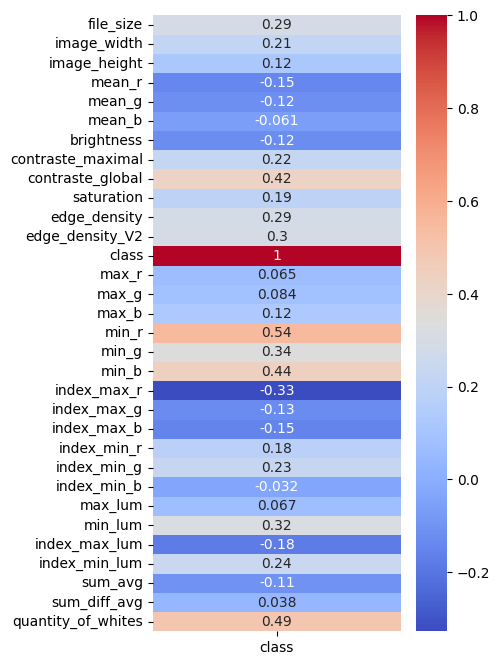

In [192]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(4, 8))
sns.heatmap(corr_matrix[['class']], cmap='coolwarm', annot = True)
plt.show()

We tested the correlation matrix with the initial 40 images and the correlation matrix with additional images classified by hand (132 images in total)

Test with 20 images from each side, we keep >0.15 and <-0.15
- file_size
- image_width
- image_height
- mean_r
- mean_g
- brightness
- contraste_global
- edge_density_V2
- max_r
- max_g
- max_b
- min_r
- min_g
- min_b
- index_max_r
- index_max_g
- max_lum
- min_lum
- index_max_lum
- index_min_lum
- sum_avg
- quantities_of_whites

test with 66 images from each side, we keep >0.1 and <0.1
- file_size
- image_width
- image_height
- edge_density_V2
- max_r
- max_g
- max_b
- min_r
- min_g
- min_b
- index_max_r
- index_max_g
- index_min_b
- max_lum
- min_lum
- index_max_lum
- index_min_lum
- sum_diff_avg

We can see that some values are still here and some changed. We will do some tests and check if some values should not be kept. In the mean time, we will keep the variables from the test with the biggest number

In [193]:
df_clean = df[df['class'] == 0]
df_dirty = df[df['class'] == 1]

In [194]:
weights_test = {"mean_r":0, "mean_g":0, "brightness":0, "contraste_global":0.42, "edge_density_V2":0.3, "max_r":0, "max_g":0, "max_b":0, "min_r":0.55, "min_g":0, "min_b":0.45, "index_max_r":0, "index_max_g":0, "max_lum":0, "min_lum":0.33, "index_max_lum":0, "index_min_lum":0, "sum_avg":0, "quantity_of_whites":0.49}

In [195]:
thresholds_test = [50, 75]

In [199]:
def score_to_class(score, thresholds):
    if score < thresholds[0]:
        clean_class = "clean"
    # elif thresholds[0] <= score <= thresholds[1]:
    #     clean_class = "dirty"
    else:
        clean_class = "very_dirty"
    return clean_class

def compute_score(img_features, weights):
    cleaness_score = sum([img_features[k]*v for k,v in weights.items()])
    return cleaness_score*100

In [200]:
def predict(df, weights, thresholds):
    y_pred = []
    for index, row in df.iterrows():
        y_pred.append(score_to_class(compute_score(row, weights), thresholds))
    return y_pred

In [201]:
y_pred_str = predict(df, weights_test, thresholds_test)
y_pred = le.transform(y_pred_str)

Accuracy :  0.6777777777777778
Rapport de classification:
               precision    recall  f1-score   support

           0       1.00      0.56      0.72        66
           1       0.45      1.00      0.62        24

    accuracy                           0.68        90
   macro avg       0.73      0.78      0.67        90
weighted avg       0.85      0.68      0.69        90



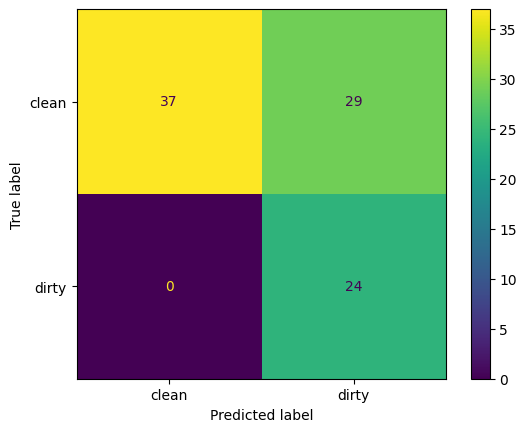

In [202]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_true = df['class']

conf_matrix = confusion_matrix(y_true, y_pred)
plt = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['clean', 'dirty'])
plt.plot()

print('Accuracy : ', accuracy_score(y_true, y_pred))
# print("Precision:", precision_score(y_true, y_pred))
# print("Recall:", recall_score(y_true, y_pred))
# print("F1 Score:", f1_score(y_true, y_pred))
print("Rapport de classification:\n", classification_report(y_true, y_pred))

In [203]:
from sklearn.model_selection import ParameterSampler
from scipy.stats import uniform

weights_base = ["mean_r", "mean_g", "brightness", "contraste_global", "edge_density_V2", "max_r", "max_g", "max_b", "min_r", "min_g", "min_b", "index_max_r", "index_max_g", "max_lum", "min_lum", "index_max_lum", "index_min_lum", "sum_avg", "quantity_of_whites"]

param_distributions = {k: uniform(0.0, 1.0) for k in weights_base}
n_iter = 5000
sampler = ParameterSampler(param_distributions, n_iter=n_iter, random_state=2)

col1 = np.random.uniform(1.0, 100.0, size=5000)
col2 = np.random.uniform(col1, 100.0)
thresholds = np.column_stack((col1, col2))

max_accuracy = 0
save_weights = None
save_threshold = None

i = 0
for sample in sampler:
    y_pred_str = predict(df, sample, thresholds[i])
    y_pred = le.transform(y_pred_str)
    accuracy = accuracy_score(y_true, y_pred)
    if accuracy>max_accuracy:
        save_weights = sample
        max_accuracy = accuracy
        save_threshold = thresholds[i]
    i+=1

print(max_accuracy)

0.36666666666666664


Create random population

In [204]:
import time

class Element :
    def __init__(self):
        weights_base = ["mean_r", "mean_g", "brightness", "contraste_global", "edge_density_V2", "max_r", "max_g", "max_b", "min_r", "min_g", "min_b", "index_max_r", "index_max_g", "max_lum", "min_lum", "index_max_lum", "index_min_lum", "sum_avg", "quantity_of_whites"]

        weights_values = np.random.rand(19)
        self.weights = {}
        for i in range(len(weights_base)):
            self.weights[weights_base[i]] = weights_values[i]

        random1 = np.random.randint(100)
        random2 = np.random.randint(random1, 100)
        self.threshold = [random1, random2]

    def get_accuracy(self):
        y_pred_str = predict(df, self.weights, self.threshold)
        y_pred = le.transform(y_pred_str)
        return accuracy_score(y_true, y_pred)

def create_pop(number_element):
    pop = []
    for i in range(number_element):
        pop.append(Element())
    return pop

def get_best(pop):
    sorted_pop = sorted(pop, key=lambda elem: elem.get_accuracy(), reverse = True)
    return sorted_pop[:len(pop)//2]

def get_child(element1, element2):
    child1 = Element()
    child2 = Element()
    i = 0
    for key in element1.weights:
        if i%2 == 0:
            child1.weights[key] = element1.weights[key]
            child2.weights[key] = element2.weights[key]
        else:
            child2.weights[key] = element1.weights[key]
            child1.weights[key] = element2.weights[key]
        i+=1
    thresholds_for_children = [np.mean([element1.threshold[0], element2.threshold[0]]), np.mean([element1.threshold[1], element2.threshold[1]])]
    thresholds_for_children.sort()
    child1.threshold = thresholds_for_children.copy()
    child2.threshold = thresholds_for_children.copy()
    return child1, child2

def mutation(element):
    for key in element.weights:
        if(np.random.rand()>0.5):
            if(np.random.rand()>0.5):
                element.weights[key] += np.random.rand()
                if element.weights[key] >1:
                    element.weights[key] = 1
            else:
                element.weights[key] -= np.random.rand()
                if element.weights[key] <0:
                    element.weights[key] = 0

    for i in range(len(element.threshold)):
        if np.random.rand()>0.5:
            element.threshold[i] += 10
            if element.threshold[i] > 100:
                element.threshold[i] = 100
        else:
            element.threshold[i] -= 10
            if element.threshold[i] < 0:
                element.threshold[i] = 0

    return element

In [205]:
population = create_pop(100)
for i in range(500):
    best_pop = get_best(population)
    children = []
    for j in range(0, len(best_pop), 2):
        child1, child2 = get_child(best_pop[j], best_pop[j+1])
        children.append(child1)
        children.append(child2)
    for element in best_pop:
        mutation(element)

    population = best_pop[:-10] + children + create_pop(10)

sorted_pop = sorted(population, key=lambda elem: elem.get_accuracy(), reverse = True)
print(sorted_pop[0].get_accuracy())

0.8666666666666667


In [206]:
element = sorted_pop[0]
print(element.weights)
print(element.threshold)

{'mean_r': 0, 'mean_g': 0, 'brightness': 0.0049338557973878094, 'contraste_global': 0, 'edge_density_V2': 1, 'max_r': 0, 'max_g': 0, 'max_b': 0.2078102369190713, 'min_r': 0.0510204492402635, 'min_g': 0, 'min_b': np.float64(0.07027425330850356), 'index_max_r': 0, 'index_max_g': 0.1847872258204224, 'max_lum': 0, 'min_lum': 0, 'index_max_lum': 0.03136570768982094, 'index_min_lum': 0.25159758350520045, 'sum_avg': 0, 'quantity_of_whites': 0.5413615510748238}
[np.float64(80.97214135313273), np.float64(91.94952885107531)]


Accuracy :  0.8666666666666667
Rapport de classification:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92        66
           1       1.00      0.50      0.67        24

    accuracy                           0.87        90
   macro avg       0.92      0.75      0.79        90
weighted avg       0.89      0.87      0.85        90



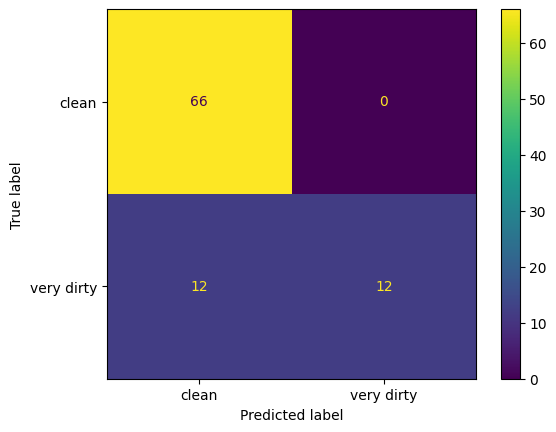

In [208]:
y_pred_str = predict(df, element.weights, element.threshold)
y_pred = le.transform(y_pred_str)

conf_matrix = confusion_matrix(y_true, y_pred)
plt = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['clean',  'very dirty'])
plt.plot()

print('Accuracy : ', accuracy_score(y_true, y_pred))
print("Rapport de classification:\n", classification_report(y_true, y_pred))